## Ejercicio hiperparametrización breast cancer de sklearn

1. Carga el dataset [breast_cancer de `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)
2. Prueba al menos 5 modelos diferentes de clasificación y aplica un GridSearchCV mediante Pipelines. Aplica también un RandomizedSearchCV.
3. Conclusiones. Guarda el modelo final en un archivo con pickle.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [3]:
%matplotlib inline
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [4]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
print(data['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [6]:
df = pd.DataFrame(data['data'], columns=data['feature_names'])
df['target'] = data['target']
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [9]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [10]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [11]:
from ydata_profiling import ProfileReport

C:\Users\titea\AppData\Local\Temp\ipykernel_4544\44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [12]:
profile = ProfileReport(df, title="Profiling Report")
profile.to_file("your_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:00<?, ?it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

[]

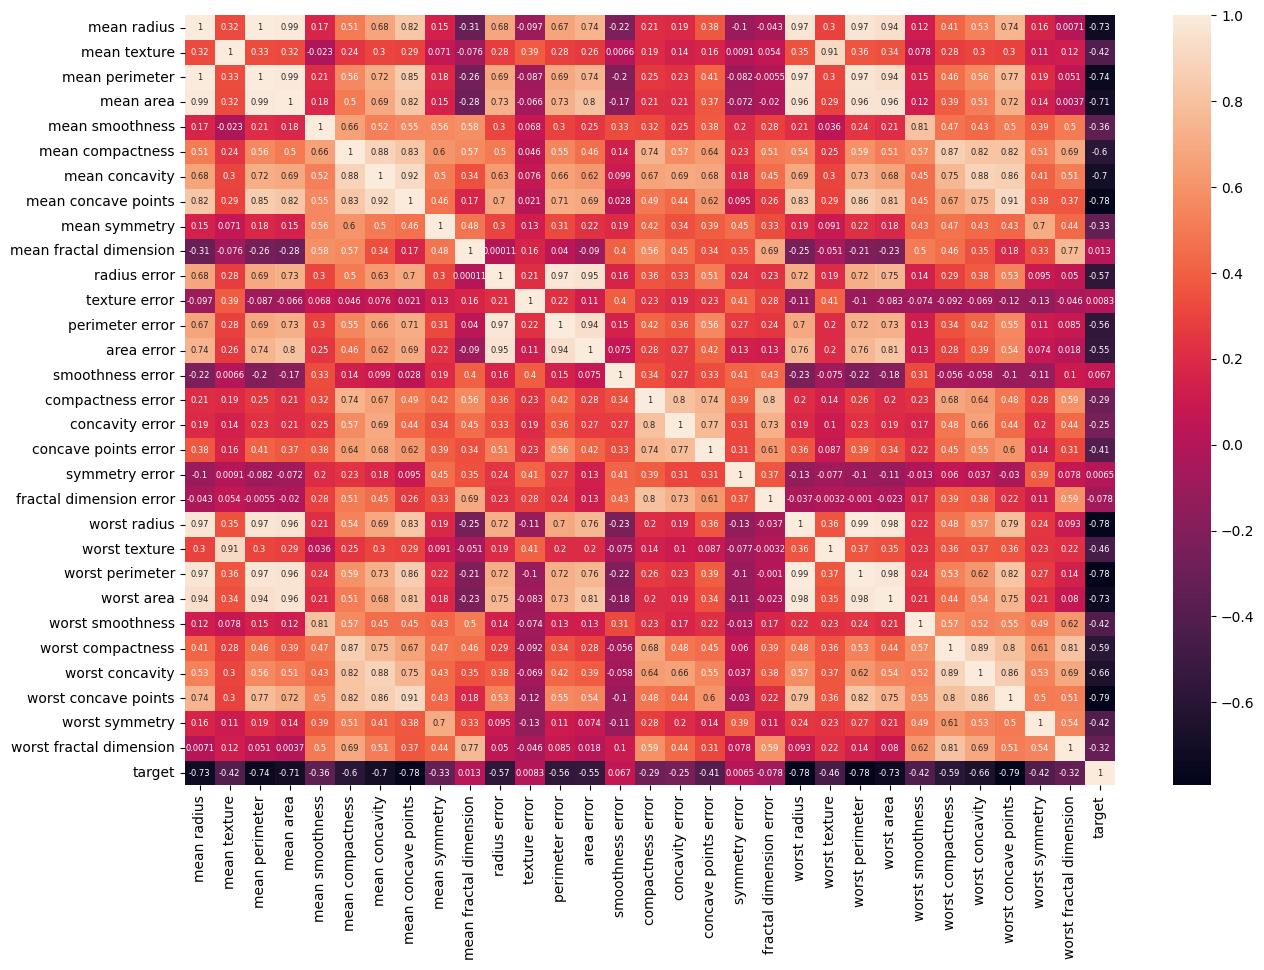

In [13]:

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, annot_kws={"size": 6})
plt.plot()

<Axes: xlabel='mean perimeter', ylabel='mean area'>

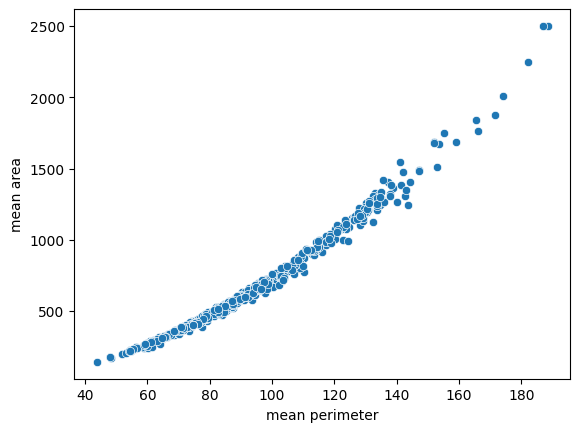

In [14]:
sns.scatterplot(x=df['mean perimeter'], y=df['mean area'])

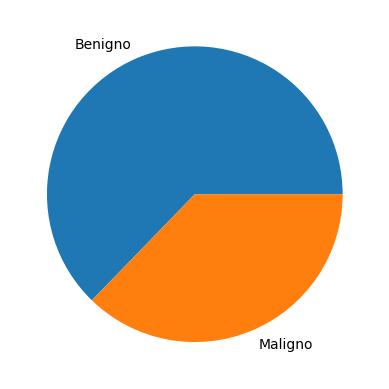

In [15]:
plt.pie(x=df['target'].value_counts(), labels=['Benigno', "Maligno"]);

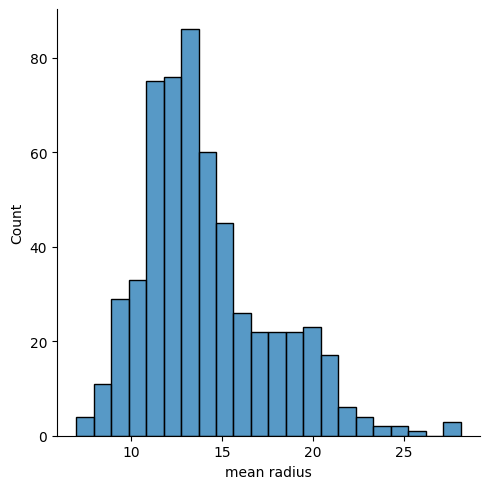

In [16]:
sns.displot(df['mean radius'])

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="target")
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [18]:

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score,make_scorer

In [19]:
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest()),
    ("classifier", RandomForestClassifier())
])

In [20]:
log_params = {
    "feature_selection__k": np.arange(5,15),
    "classifier": [LogisticRegression()],
    "classifier__C": [0.1,1,10]
}

In [21]:
rf_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "feature_selection__k": np.arange(10,15),
    "classifier__max_depth": [3,5,7]
}

In [22]:
gb_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "feature_selection__k": np.arange(10,15),
    "classifier": [GradientBoostingClassifier()],
    "classifier__max_depth": [3,5,7]
}

In [23]:
knn_params = {
    "feature_selection__k": np.arange(5,15),
    "classifier": [KNeighborsClassifier()],
    "classifier__n_neighbors": np.arange(5,15)
}

In [24]:
svm_params = {
    "feature_selection__k": np.arange(5,15),
    "classifier": [SVC()],
    "classifier__C": [0.1,1,10],
    "classifier__kernel": ["linear", "rbf"]
}

In [25]:
search_space = [
    log_params,
    rf_params,
    gb_params,
    knn_params,
    svm_params
]

In [26]:
clf_gs = GridSearchCV(pipe, search_space, cv=3, scoring=make_scorer(recall_score, pos_label=0), verbose=2, n_jobs=-1)

In [27]:
clf_gs.fit(X_train, y_train)

Fitting 3 folds for each of 280 candidates, totalling 840 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier': [LogisticRegression()], 'classifier__C': [0.1, 1, ...], 'feature_selection__k': array([ 5, 6..., 12, 13, 14])}, {'classifier__max_depth': [3, 5, ...], 'feature_selection__k': array([10, 11, 12, 13, 14]), 'scaler': [StandardScaler(), MinMaxScaler(), ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(r..., pos_label=0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defaul

In [28]:
print(clf_gs.best_estimator_)
print(clf_gs.best_score_)
print(clf_gs.best_params_)

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k=np.int64(8))),
                ('classifier', LogisticRegression(C=10))])
0.9288847117794486
{'classifier': LogisticRegression(), 'classifier__C': 10, 'feature_selection__k': np.int64(8)}


In [29]:
final_model = clf_gs.best_estimator_
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

In [30]:
print("accuracy_score", accuracy_score(y_test, y_pred))
print("precision_score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("roc_auc_score", roc_auc_score(y_test, y_pred))
print("confusion_matrix\n", confusion_matrix(y_test, y_pred))

accuracy_score 0.9824561403508771
precision_score 0.9859154929577465
recall_score 0.9859154929577465
roc_auc_score 0.9813298395021289
confusion_matrix
 [[42  1]
 [ 1 70]]


In [31]:
np.logspace(-3,3,100)

array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-02, 2.15443469e-02, 2.47707636e-02,
       2.84803587e-02, 3.27454916e-02, 3.76493581e-02, 4.32876128e-02,
       4.97702356e-02, 5.72236766e-02, 6.57933225e-02, 7.56463328e-02,
       8.69749003e-02, 1.00000000e-01, 1.14975700e-01, 1.32194115e-01,
       1.51991108e-01, 1.74752840e-01, 2.00923300e-01, 2.31012970e-01,
       2.65608778e-01, 3.05385551e-01, 3.51119173e-01, 4.03701726e-01,
       4.64158883e-01, 5.33669923e-01, 6.13590727e-01, 7.05480231e-01,
       8.11130831e-01, 9.32603347e-01, 1.07226722e+00, 1.23284674e+00,
       1.41747416e+00, 1.62975083e+00, 1.87381742e+00, 2.15443469e+00,
      

In [32]:
log_params = {
    "feature_selection__k": np.arange(5,15),
    "classifier": [LogisticRegression()],
    "classifier__C": np.logspace(-3,3,100)
}
rf_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "feature_selection__k": np.arange(10,15),
    "classifier__max_depth": np.arange(2,10)
}
gb_params = {
    "scaler": [StandardScaler(), MinMaxScaler(), None],
    "feature_selection__k": np.arange(10,15),
    "classifier": [GradientBoostingClassifier()],
    "classifier__max_depth": [3,5,7],
    "classifier__learning_rate":np.logspace(-3,3,100)
}
knn_params = {
    "feature_selection__k": np.arange(5,15),
    "classifier": [KNeighborsClassifier()],
    "classifier__n_neighbors": np.arange(5,15)
}
svm_params = {
    "feature_selection__k": np.arange(5,15),
    "classifier": [SVC()],
    "classifier__C": np.logspace(-3,3,100),
    "classifier__kernel": ["linear", "rbf"]
}
search_space = [
    log_params,
    rf_params,
    gb_params,
    knn_params,
    svm_params
]

In [33]:
clf_gs = RandomizedSearchCV(pipe, search_space, cv=3, scoring="accuracy", verbose=2, n_jobs=-1, n_iter=280)
clf_gs.fit(X_train, y_train)

print(clf_gs.best_estimator_)
print(clf_gs.best_score_)
print(clf_gs.best_params_)

final_model_2 = clf_gs.best_estimator_
final_model_2.fit(X_train, y_train)
y_pred = final_model_2.predict(X_test)

print("accuracy_score", accuracy_score(y_test, y_pred))
print("precision_score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("roc_auc_score", roc_auc_score(y_test, y_pred))
print("confusion_matrix\n", confusion_matrix(y_test, y_pred))


Fitting 3 folds for each of 280 candidates, totalling 840 fits
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k=np.int64(10))),
                ('classifier', SVC(C=np.float64(20.09233002565046)))])
0.9582171488323458
{'feature_selection__k': np.int64(10), 'classifier__kernel': 'rbf', 'classifier__C': np.float64(20.09233002565046), 'classifier': SVC()}
accuracy_score 0.9736842105263158
precision_score 0.9722222222222222
recall_score 0.9859154929577465
roc_auc_score 0.969701932525385
confusion_matrix
 [[41  2]
 [ 1 70]]


In [34]:
from sklearn.metrics import make_scorer, recall_score

# Crear un scorer personalizado para el recall de la clase negativa
negative_class_recall_scorer = make_scorer(recall_score, pos_label=0)
positive_class_recall_scorer = make_scorer(recall_score, pos_label=1)

In [35]:
clf_gs = RandomizedSearchCV(pipe, search_space, cv=3, scoring=positive_class_recall_scorer, verbose=2, n_jobs=-1,n_iter=280)
clf_gs.fit(X_train, y_train)

print(clf_gs.best_estimator_)
print(clf_gs.best_score_)
print(clf_gs.best_params_)

final_model_2 = clf_gs.best_estimator_
final_model_2.fit(X_train, y_train)
y_pred = final_model_2.predict(X_test)

print("accuracy_score", accuracy_score(y_test, y_pred))
print("precision_score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("roc_auc_score", roc_auc_score(y_test, y_pred))
print("confusion_matrix\n", confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 280 candidates, totalling 840 fits
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k=np.int64(13))),
                ('classifier', SVC(C=np.float64(0.005336699231206312)))])
1.0
{'feature_selection__k': np.int64(13), 'classifier__kernel': 'rbf', 'classifier__C': np.float64(0.005336699231206312), 'classifier': SVC()}
accuracy_score 0.6228070175438597
precision_score 0.6228070175438597
recall_score 1.0
roc_auc_score 0.5
confusion_matrix
 [[ 0 43]
 [ 0 71]]


In [36]:
from sklearn.model_selection import cross_val_score

results_cv_1 = cross_val_score(final_model, X, y, scoring="accuracy", cv=10)
print(results_cv_1.mean())

results_cv_2 = cross_val_score(final_model_2, X, y, scoring="accuracy", cv=10)
print(results_cv_2.mean())

0.9595864661654134
0.6274122807017544


In [37]:
import pickle

In [38]:
import os
os.getcwd()

'c:\\Users\\titea\\Bootcamp\\REPOS\\2026-02-BILBAO-FT-Data-Science\\3-Machine_Learning\\1-Supervisado\\4-Pipelines\\ejercicios'

In [39]:
filename = "final_model"

with open(filename, "wb") as archivo_salida:
    pickle.dump(final_model_2, archivo_salida)

In [40]:
with open(filename, "rb") as archivo_entrada:
    modelo_importado = pickle.load(archivo_entrada)

In [41]:
modelo_importado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...00199E8D35F80>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",np.int64(13)
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(0....6699231206312)
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'


In [42]:
from sklearn.metrics import make_scorer, recall_score

# Crear un scorer personalizado para el recall de la clase negativa
negative_class_recall_scorer = make_scorer(recall_score, pos_label=0)

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Crear un dataset de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Definir un modelo
model = RandomForestClassifier(random_state=42)

# Definir el rango de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [ 10, 20],
}

# Crear el GridSearchCV con el scorer personalizado
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=negative_class_recall_scorer,
    cv=5,
    verbose=1
)

# Ejecutar el grid search
grid_search.fit(X, y)

# Mostrar los mejores parámetros
print("Mejores parámetros:", grid_search.best_params_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros: {'max_depth': 10, 'n_estimators': 50}


In [44]:


print(grid_search.best_estimator_)
print(grid_search.best_score_)
print(grid_search.best_params_)

final_model_3 = grid_search.best_estimator_
final_model_3.fit(X, y)
y_pred = final_model_3.predict(X)

print("accuracy_score", accuracy_score(y, y_pred))
print("precision_score", precision_score(y, y_pred))
print("recall_score", recall_score(y, y_pred))
print("roc_auc_score", roc_auc_score(y, y_pred))
print("confusion_matrix\n", confusion_matrix(y, y_pred))

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)
0.916
{'max_depth': 10, 'n_estimators': 50}
accuracy_score 0.992
precision_score 1.0
recall_score 0.984
roc_auc_score 0.992
confusion_matrix
 [[500   0]
 [  8 492]]


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Crear un dataset de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Definir un modelo
model = RandomForestClassifier(random_state=42)

# Definir el rango de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [ 10, 20],
}

# Crear el GridSearchCV con el scorer personalizado
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=negative_class_recall_scorer,
    cv=5,
    verbose=1
)

# Ejecutar el grid search
grid_search.fit(X, y)

# Mostrar los mejores parámetros
print("Mejores parámetros:", grid_search.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros: {'max_depth': 10, 'n_estimators': 50}


In [46]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score,confusion_matrix

print(grid_search.best_estimator_)
print(grid_search.best_score_)
print(grid_search.best_params_)

final_model_3 = grid_search.best_estimator_
final_model_3.fit(X, y)
y_pred = final_model_3.predict(X)

print("accuracy_score", accuracy_score(y, y_pred))
print("precision_score", precision_score(y, y_pred))
print("recall_score", recall_score(y, y_pred))
print("roc_auc_score", roc_auc_score(y, y_pred))
print("confusion_matrix\n", confusion_matrix(y, y_pred))

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)
0.916
{'max_depth': 10, 'n_estimators': 50}
accuracy_score 0.992
precision_score 1.0
recall_score 0.984
roc_auc_score 0.992
confusion_matrix
 [[500   0]
 [  8 492]]
